In [1]:
import random
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc,
)
import nibabel as nib
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score, recall_score
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib import rcParams
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score, recall_score
)

import matplotlib.pyplot as plt
import seaborn as sns  # optional, only if you actually use its styling/helpers
from tqdm import tqdm

# Local/project modules — avoid wildcards if you can, e.g., import only what's used
from run_models import train, test
from models import *  # ideally replace with explicit imports: e.g., from models import SomeModelClass
from ConvolutionalAE import ConvolutionalAE_upd

from utils import *
### CONV AE
from sklearn.model_selection import train_test_split
# from skimage.measure import find_contours


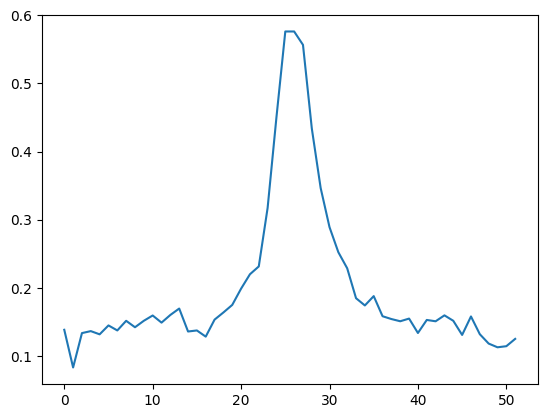

In [2]:

# Load data
#rat_data_postGAD = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
rat_data_postGAD = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
#rat_data_postGAD = np.load('data/ratTumorData_updated_preGd_meme.npz')
Rat_Z_Spectras = 1- rat_data_postGAD['zspec']
Rat_Healthy_Idx = rat_data_postGAD['voxelInds_healthy']
Rat_Tumor_Idx = rat_data_postGAD['voxelInds_tumor']
rat_healthy_all = Rat_Z_Spectras[Rat_Healthy_Idx]
rat_tumor_all = Rat_Z_Spectras[Rat_Tumor_Idx]

plt.plot(rat_healthy_all[0])


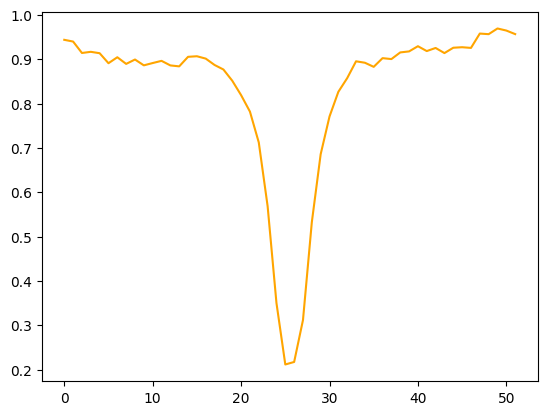

In [3]:

plt.plot(1-rat_tumor_all[100], color = "orange")

In [4]:
rat_data_HEALTHY_TRAIN = np.load('data/ratData_healthy_all4_rats.npz')
Rat_Z_Spectras_HEALTHY_TRAIN = 1- rat_data_HEALTHY_TRAIN['zspec']
Rat_Healthy_Idx__HEALTHY_TRAIN = rat_data_HEALTHY_TRAIN['voxelInds_healthy']
rat_healthy_all_HEALTHY_TRAIN = Rat_Z_Spectras_HEALTHY_TRAIN[Rat_Healthy_Idx__HEALTHY_TRAIN]


In [5]:
top26= np.load("data/SelectedFeatures.npz", allow_pickle=True)['top26']

In [6]:
top26.item()['inds']

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 35, 36, 38, 40, 41,
       43, 44, 45, 46, 47, 48, 49, 50, 51])

In [7]:
top26Indx = top26.item()['offsets']

In [8]:
N = rat_healthy_all.shape[1]           # 52
n_sparse = 26
# top26Indx = [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 35, 36, 38, 40, 41,
#        43, 44, 45, 46, 47, 48, 49, 50, 51]
top26Indx = top26.item()['inds']
sparse_idxs = top26Indx
# sparse_idxs = np.linspace(0, N-1, n_sparse, dtype=int)
Rat_Healthy_Idx_sparse = Rat_Healthy_Idx
Rat_Tumor_Idx_sparse =Rat_Tumor_Idx
rat_healthy_all_sparse = rat_healthy_all[:, sparse_idxs]  # shape = (11483, 10)
rat_tumor_all_sparse = rat_tumor_all[:,sparse_idxs]
Rat_Z_Spectras_sparse = Rat_Z_Spectras[:,sparse_idxs]

Rat_Healthy_Idx__HEALTHY_TRAIN_sparse = Rat_Healthy_Idx__HEALTHY_TRAIN
rat_healthy_all_HEALTHY_TRAIN_sparse= rat_healthy_all_HEALTHY_TRAIN[:,sparse_idxs]
Rat_Z_Spectras_HEALTHY_TRAIN_sparse = Rat_Z_Spectras_HEALTHY_TRAIN[:,sparse_idxs]

(147456, 26)


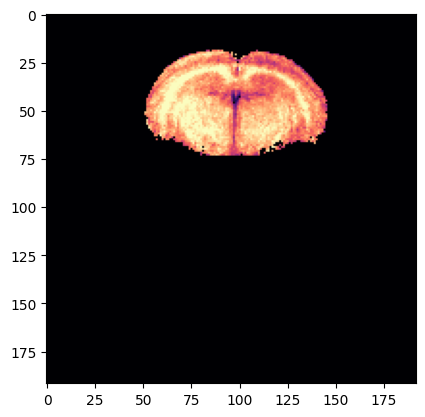

In [9]:
# --- Reconstruct Original Image ---
Healthy_Voxel_img_train = Rat_Z_Spectras_HEALTHY_TRAIN_sparse
inds = Rat_Healthy_Idx__HEALTHY_TRAIN_sparse
tempImg = np.zeros((4,192,192,26))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_HEALTHY_TRAIN_sparse     # Assign values at indexed positions
Healthy_Voxel_img_train = tempImg_flat.reshape((4,192,192,26))  # Reshape back
Healthy_Voxel_img_train.shape
Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 26)
print(Train_Image_Set.shape)
Train_Image_Set_indx = np.where(Train_Image_Set.sum(axis=1) >0)
train_extracted = Train_Image_Set[Train_Image_Set_indx]
train_extracted.shape

plt.imshow(Healthy_Voxel_img_train[3,:,:,0], vmin = 0, vmax=0.35, cmap='magma')



In [10]:
train_extracted.shape

(16548, 26)

In [11]:
print(Train_Image_Set.shape)

(147456, 26)


In [12]:
# --- Reconstruct Original Image ---
Tumor_Voxel_img =1- Rat_Z_Spectras_sparse
inds = Rat_Tumor_Idx
tempImg = np.zeros((4, 192, 192,26)) # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_tumor_all_sparse # Assign values at indexed positions
Tumor_Voxel_img = tempImg_flat.reshape((4, 192, 192,26))  # Reshape back
Tumor_Voxel_img.shape

(4, 192, 192, 26)

(4, 192, 192, 26)


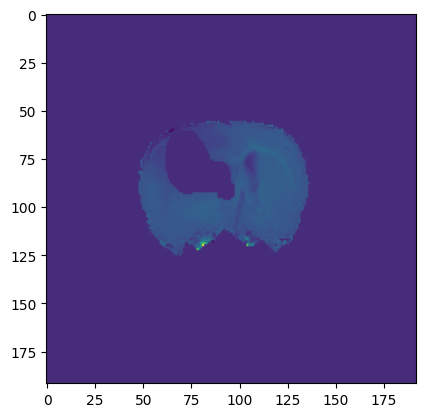

In [13]:
# --- Reconstruct Original Image ---
rat_image_shape = (4,192,192,26)
Healthy_Voxel_img_postGAD = Rat_Z_Spectras_sparse
inds = Rat_Healthy_Idx_sparse
tempImg = np.zeros(rat_image_shape)  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_sparse   # Assign values at indexed positions
Healthy_Voxel_img_postGAD = tempImg_flat.reshape(rat_image_shape)  # Reshape back
print(Healthy_Voxel_img_postGAD.shape)
plt.imshow(Healthy_Voxel_img_postGAD[2,:,:,0])


In [14]:


Test_Image_Set = Tumor_Voxel_img.reshape(-1, 26)
print(Test_Image_Set.shape)
Test_Image_Set_indx = np.where(Test_Image_Set.sum(axis=1) > 0)[0]
Healthy_test = Healthy_Voxel_img_postGAD.reshape(-1, 26)
Healthy_test_idx = np.where(Healthy_test.sum(axis=1) > 0)[0]
test_idx =np.concatenate([Test_Image_Set_indx,Healthy_test_idx])
print(Test_Image_Set_indx.shape)




(147456, 26)
(1495,)


In [15]:


test_extracted= np.concatenate([Rat_Z_Spectras_sparse[Test_Image_Set_indx],Rat_Z_Spectras_sparse[Healthy_test_idx]], axis=0)
test_extracted.shape
Test_img =Rat_Z_Spectras_sparse
inds = test_idx
tempImg = np.zeros((4,192,192,26))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  test_extracted      # Assign values at indexed positions
Test_img = tempImg_flat.reshape((4,192,192,26))  # Reshape back
print(Test_img.shape)


(4, 192, 192, 26)


In [16]:

Healthy_Voxel_img_all   = Healthy_Voxel_img_train
Healthy_Voxel_img_train = Healthy_Voxel_img_all[:3]        
Healthy_Voxel_img_val   = Healthy_Voxel_img_all[-1]       

Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 26)
Val_Image_Set   = Healthy_Voxel_img_val.reshape(-1, 26)

train_extracted = Train_Image_Set
val_extracted   = Val_Image_Set
print("train_extracted:", train_extracted.shape)
print("val_extracted:  ", val_extracted.shape)

rat_train_data   = train_extracted
rat_val_data     = val_extracted
rat_test_data    = test_extracted

rat_train_labels = np.ones(len(rat_train_data), dtype=int)   # all healthy
rat_val_labels   = np.ones(len(rat_val_data),   dtype=int)   # all healthy
rat_test_labels  = np.concatenate(
    [np.ones(len(Test_Image_Set_indx)), np.zeros(len(Healthy_test_idx))],
    axis=0
).astype(int)

print("Train data shape:", rat_train_data.shape)
print("Val   data shape:", rat_val_data.shape)
print("Test  data shape:", rat_test_data.shape)
print("Train label counts:", np.unique(rat_train_labels, return_counts=True))
print("Val   label counts:", np.unique(rat_val_labels,   return_counts=True))
print("Test  label counts:", np.unique(rat_test_labels,  return_counts=True))

# ---- Torch tensors & loaders ----
X_train = torch.from_numpy(rat_train_data).float().unsqueeze(1)  # (N,1,52)
X_val   = torch.from_numpy(rat_val_data).float().unsqueeze(1)
X_test  = torch.from_numpy(rat_test_data).float().unsqueeze(1)

print("new shape: ", X_train.shape, X_val.shape, X_test.shape)

train_ds = TensorDataset(X_train)
val_ds   = TensorDataset(X_val)
test_ds  = TensorDataset(X_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

# Keep for evaluation if needed
y_train, y_val, y_test = rat_train_labels, rat_val_labels, rat_test_labels


train_extracted: (110592, 26)
val_extracted:   (36864, 26)
Train data shape: (110592, 26)
Val   data shape: (36864, 26)
Test  data shape: (14243, 26)
Train label counts: (array([1]), array([110592]))
Val   label counts: (array([1]), array([36864]))
Test  label counts: (array([0, 1]), array([12748,  1495]))
new shape:  torch.Size([110592, 1, 26]) torch.Size([36864, 1, 26]) torch.Size([14243, 1, 26])


In [17]:
R, H, W, O = Tumor_Voxel_img.shape
assert O == 26, f"Expected 26 offsets, got {O}"

VAL_RAT_ID = 2  # hold out rat index 0/1/2 for pathological validation

block = H * W
start = VAL_RAT_ID * block
end   = start + block

# Masks to select flat indices for the held-out rat
tumor_mask_val   = (Test_Image_Set_indx >= start) & (Test_Image_Set_indx < end)
healthy_mask_val = (Healthy_test_idx   >= start)  & (Healthy_test_idx   < end)

# Indices for the held-out rat (unhealthy validation) vs remaining two rats (actual test)
tumor_idx_val    = Test_Image_Set_indx[tumor_mask_val]
healthy_idx_val  = Healthy_test_idx[healthy_mask_val]
tumor_idx_test   = Test_Image_Set_indx[~tumor_mask_val]
healthy_idx_test = Healthy_test_idx[~healthy_mask_val]

# --- CRITICAL: gather rows from the 26-offset matrix ---
val_unhealthy_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_val],
    Rat_Z_Spectras_sparse[healthy_idx_val]
]).astype(np.float32)  # (N_val_unhealthy, 26)

rat_test_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_test],
    Rat_Z_Spectras_sparse[healthy_idx_test]
]).astype(np.float32)  # (N_test, 26)

# Labels: tumor=1, healthy=0
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),
    np.zeros(len(healthy_idx_val), dtype=int)
])
y_test = np.concatenate([
    np.ones(len(tumor_idx_test),    dtype=int),
    np.zeros(len(healthy_idx_test), dtype=int)
])

print("Held-out Unhealthy VAL (26):", val_unhealthy_extracted.shape, y_val_unhealthy.shape)
print("Two-rat TEST (26):          ", rat_test_extracted.shape,      y_test.shape)

# ---- Replace ONLY the test set with the two-rat split; keep train/healthy-val the same ----
rat_test_data   = rat_test_extracted
rat_test_labels = y_test

# Tensors/loaders (keep train/healthy-val unchanged)
X_test          = torch.from_numpy(rat_test_data).float().unsqueeze(1)           # (N,1,26)
test_loader     = DataLoader(TensorDataset(X_test), batch_size=128, shuffle=False)

# NEW: loader for the held-out pathological validation rat
X_val_unhealthy     = torch.from_numpy(val_unhealthy_extracted).float().unsqueeze(1)  # (M,1,26)
val_unhealthy_loader= DataLoader(TensorDataset(X_val_unhealthy), batch_size=128, shuffle=False)

# order matches val_unhealthy_extracted = [tumor rows; healthy rows]
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),  # 1 = tumor
    np.zeros(len(healthy_idx_val), dtype=int)   # 0 = healthy
])

print("y_val_unhealthy shape (26):", y_val_unhealthy.shape)
print("counts (26):", np.unique(y_val_unhealthy, return_counts=True))
print("first 10 labels (26):", y_val_unhealthy[:10])


Held-out Unhealthy VAL (26): (4925, 26) (4925,)
Two-rat TEST (26):           (9318, 26) (9318,)
y_val_unhealthy shape (26): (4925,)
counts (26): (array([0, 1]), array([4078,  847]))
first 10 labels (26): [1 1 1 1 1 1 1 1 1 1]


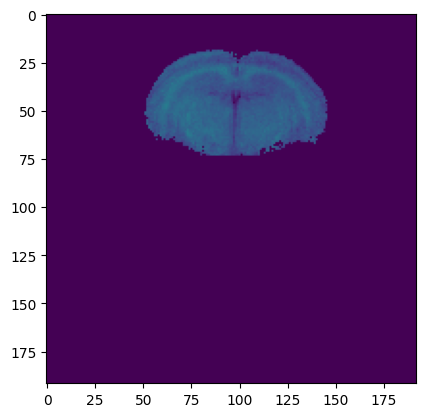

In [18]:
plt.imshow(Healthy_Voxel_img_val[:,:,0], vmin = 0, vmax =1, )

### Train Test Split 

## Load Model

In [19]:
cae_model = ConvolutionalAE_upd(seq_len=26)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#checkpoint_cae = "Checkpoints/8_Off_4_RATS.pth.pth"
#checkpoint_cae = "Checkpoints/UPDATED OFFSETS_NEW OPTIMAL/UPDATED_26_Off_B0Corrected_AMAS_best_model.pth"
#checkpoint_cae = "Checkpoints/UPDATED OFFSETS_NEW OPTIMAL/UPDATED_26_Off_B0Corrected_AMAS_best_model.pth"

checkpoint_cae = "Checkpoints/UPDATED OFFSETS_NEW OPTIMAL/sancheck_26_Off_B0Corrected_AMAS_best_model_usethis.pth"


state_dict = torch.load(checkpoint_cae, map_location=torch.device('cpu'))
cae_model.load_state_dict(state_dict)
cae_model.to(device)

ConvolutionalAE_upd(
  (conv_down1): Sequential(
    (0): Conv1d(1, 8, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
  )
  (max_pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_down2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fnn_down): Sequential(
    (0): Linear(in_features=416, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16, bias=True)
    (3): ReLU()
  )
  (fnn_up): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=416, bias=True)
    (3): ReLU()
    (4): Un

In [20]:
cae_test_results = test(cae_model,test_loader)
# cae_val_results = test(cae_model,val_loader)
cae_val_unhealthy_rec = test(cae_model, val_unhealthy_loader)

# SET VALIDATION THRESHOLD

# ###################################################################################################################################################

### Set Val Threshold

### Generate ROC

In [21]:
recon = X_test.squeeze(1)  # torch tensor, shape (N, features)
recon_errors = reconstruction_error(recon.cpu().numpy(), cae_test_results)  # (N,)
y_true = rat_test_labels  # binary array
metrics = roc_analysis(y_true, recon_errors, pos_label=1)
print("=== ROC Summary ===")
print(summary_text(metrics))


=== ROC Summary ===
AUC: 0.957
Optimal threshold (Youden's J): 0.0145
Sensitivity: 0.975
Specificity: 0.893
Fraction flagged as anomaly: 16.8%
Threshold percentile: 83.2th



In [22]:
recon = X_val_unhealthy.squeeze(1)  # torch tensor, shape (N, features)
recon_errors_val = reconstruction_error(recon.cpu().numpy(), cae_val_unhealthy_rec)  # (N,)
y_true_val = y_val_unhealthy

metrics = roc_analysis(y_true_val, recon_errors_val, pos_label=1)

print("=== ROC Summary ===")
print(summary_text(metrics))


=== ROC Summary ===
AUC: 0.891
Optimal threshold (Youden's J): 0.0063
Sensitivity: 0.950
Specificity: 0.753
Fraction flagged as anomaly: 36.8%
Threshold percentile: 63.2th



In [23]:

healthy_inds = np.where(y_true_val == 0)[0]
thrshold_percentage =0.90
threshold_unsupervised = np.quantile(recon_errors_val[healthy_inds], thrshold_percentage)  # 99th percentile
print(f"Unsupervised  = {threshold_unsupervised:.5f}")


Unsupervised  = 0.02286


In [24]:
top26.item()['offsets']

array([-5. , -4.8, -4.6, -4.4, -4.2, -4. , -3.8, -3.6, -3.4, -3.2, -3. ,
       -2.8,  1.8,  2. ,  2.4,  2.8,  3. ,  3.4,  3.6,  3.8,  4. ,  4.2,
        4.4,  4.6,  4.8,  5. ])

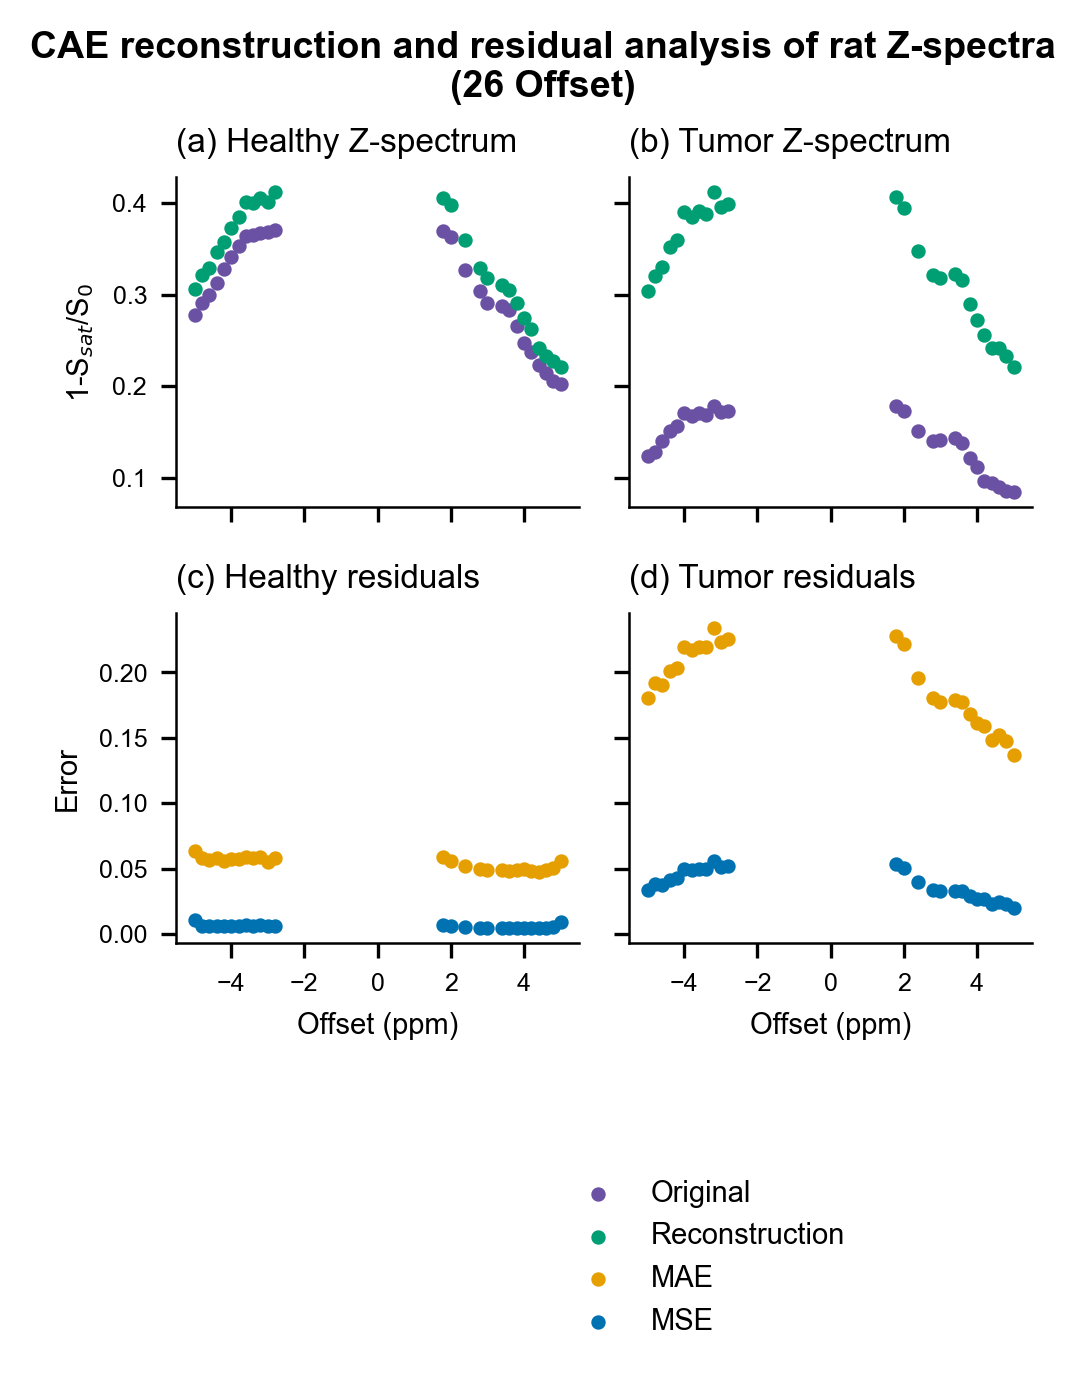

In [25]:
# assuming you’ve imported from utils:
# from utils import plot_zspec_recon_and_residuals

offset_axis =top26.item()['offsets']
# offset_axis = np.linspace(-4, 4, 26)
fig, axes = plot_zspec_recon_and_residuals_scatter(
    orig=X_test,                # (N,1,52) or (N,52) or torch.Tensor
    rec=cae_test_results,       # (N,52)
    y_true=rat_test_labels,     # (N,)
    offset_axis=offset_axis,
    save_path=None,             # e.g., "zspec_summary.pdf"
    show=True
)




C:\Users\Abeer\AppData\Local\Temp\ipykernel_20276\194635617.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.scatter(offset_axis, np.mean(np.array(X_test.squeeze()), axis = 0), label = "Healthy")


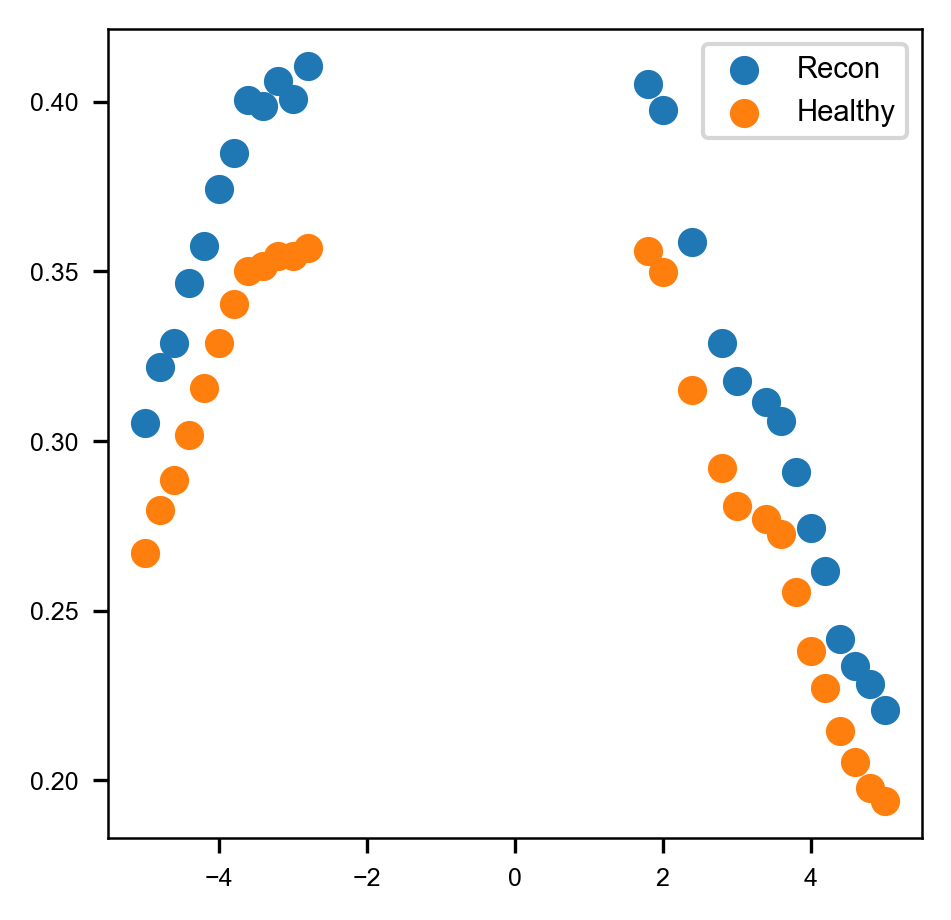

In [26]:
plt.scatter(offset_axis, np.mean(cae_test_results, axis=0), label = "Recon")
plt.scatter(offset_axis, np.mean(np.array(X_test.squeeze()), axis = 0), label = "Healthy")
plt.legend()


C:\Users\Abeer\AppData\Local\Temp\ipykernel_20276\2765791292.py:1: DeprecationWarning: This function is deprecated. Please call randint(1, 10000 + 1) instead
  rn = np.random.random_integers(10000)


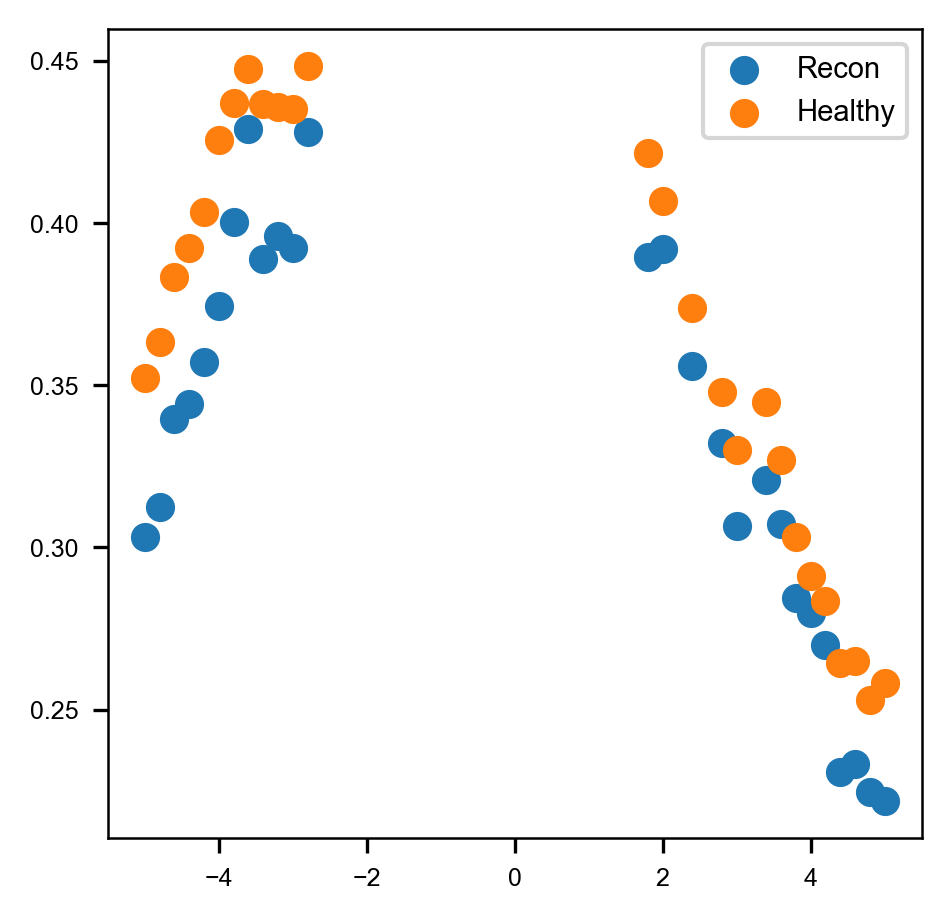

In [27]:
rn = np.random.random_integers(10000)
plt.scatter(offset_axis,cae_test_results[rn], label = "Recon")
plt.scatter(offset_axis, X_test.squeeze()[rn], label = "Healthy")
plt.legend()


In [28]:
len(cae_test_results)

9318

In [29]:
X_test.shape

torch.Size([9318, 1, 26])

In [30]:
X_test.squeeze().shape

torch.Size([9318, 26])

In [31]:

anomaly_score_val = recon_errors_val
norm_anom_score_cae = (anomaly_score_val - np.min(anomaly_score_val)) / (np.max(anomaly_score_val) - np.min(anomaly_score_val))
binary_score_val = (anomaly_score_val >=  threshold_unsupervised).astype(int)


In [32]:

anomaly_score_val = recon_errors_val.astype(float)
rng = anomaly_score_val.max() - anomaly_score_val.min()
norm_anom_score_val = (anomaly_score_val - anomaly_score_val.min()) / (rng if rng > 0 else 1.0)
binary_score_val = (anomaly_score_val >= float(threshold_unsupervised)).astype(np.uint8)

# 2) Flat index order must match how X_val_unhealthy was stacked: [tumor; healthy]
idx_order_val = np.concatenate([tumor_idx_val, healthy_idx_val])
assert idx_order_val.size == anomaly_score_val.shape[0], \
    f"VAL scores len {anomaly_score_val.shape[0]} != idx count {idx_order_val.size}"

# 3) Choose offsets dimension (26 if you built a sparse set, else 52)
if 'Rat_Z_Spectras_sparse' in globals():
    Rv, Hv, Wv, Ov = map(int, (3,192,192,26))   # e.g., (3,192,192,26)
else:
    Rv, Hv, Wv, Ov = map(int, rat_data_postGAD['imageShape']) # e.g., (3,192,192,52)

# 4) Scatter scores to flat canvas then reshape
Nvox_val = Rv * Hv * Wv
flat_norm_val = np.zeros((Nvox_val, Ov), dtype=np.float32)
flat_bin_val  = np.zeros((Nvox_val, Ov), dtype=np.uint8)

flat_norm_val[idx_order_val] = np.repeat(norm_anom_score_val[:, None], Ov, axis=1)
flat_bin_val[idx_order_val]  = np.repeat(binary_score_val[:,    None], Ov, axis=1)

anom_norm_img_val = flat_norm_val.reshape(Rv, Hv, Wv, Ov)
bin_img_val       = flat_bin_val.reshape(Rv, Hv, Wv, Ov)

# 5) Zero out non-validation rats (keep ONLY VAL_RAT_ID populated)
for ri in range(Rv):
    if ri != VAL_RAT_ID:
        anom_norm_img_val[ri] = 0.0
        bin_img_val[ri]       = 0

print("anom_norm_img_val:", anom_norm_img_val.shape,
      "| nonzero@offset0:", int((anom_norm_img_val[...,0] > 0).sum()))
print("bin_img_val:", bin_img_val.shape,
      "| positives@offset0:", int(bin_img_val[...,0].sum()))


anom_norm_img_val: (3, 192, 192, 26) | nonzero@offset0: 4924
bin_img_val: (3, 192, 192, 26) | positives@offset0: 891


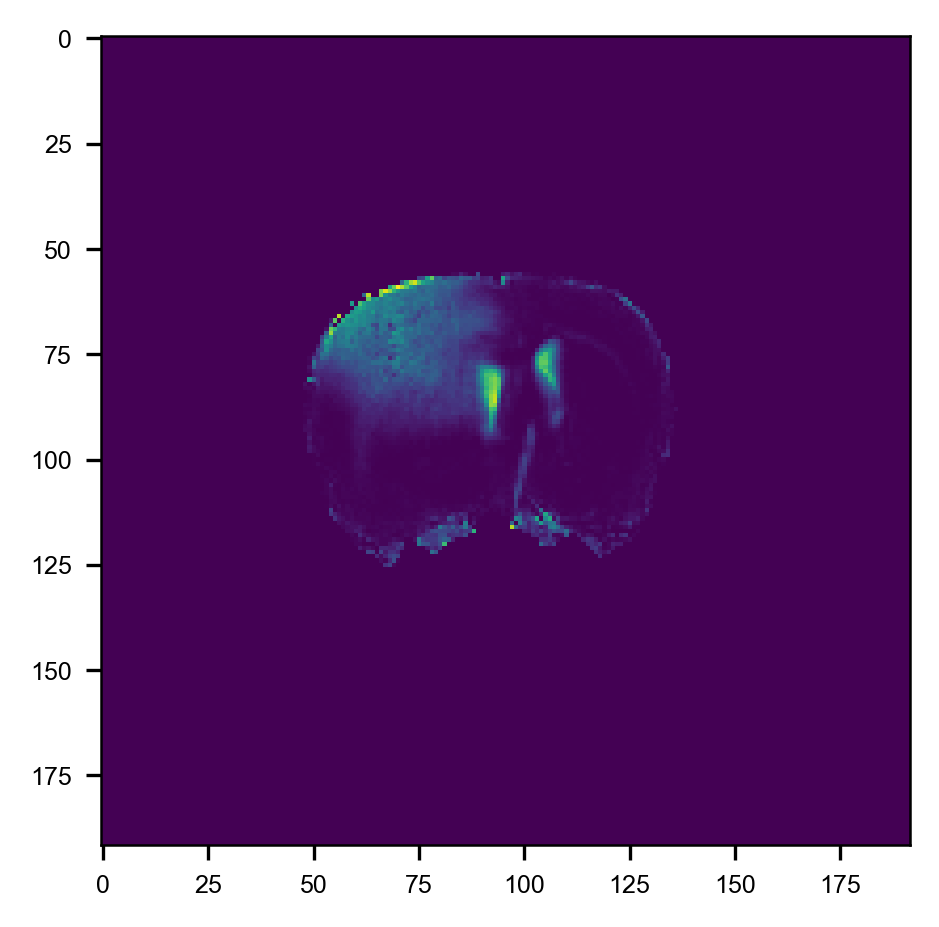

In [33]:
plt.imshow(anom_norm_img_val[2,:,:,0])


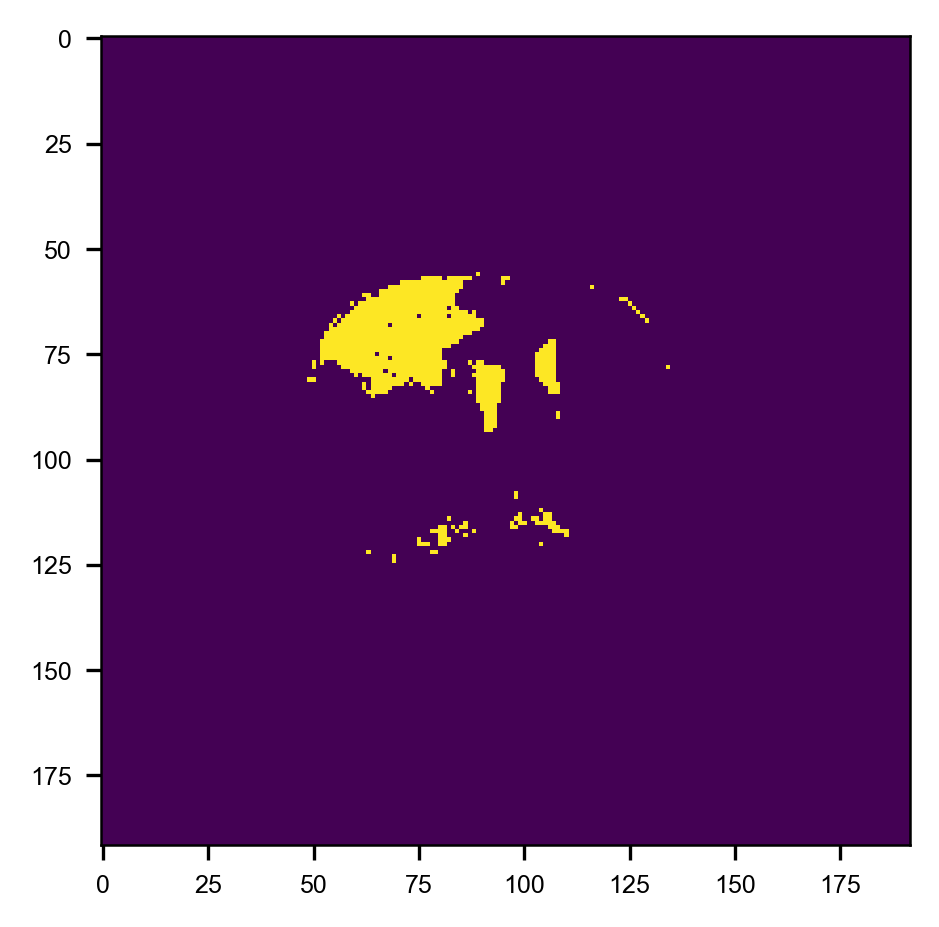

In [34]:
plt.imshow(bin_img_val[2,:,:,0])


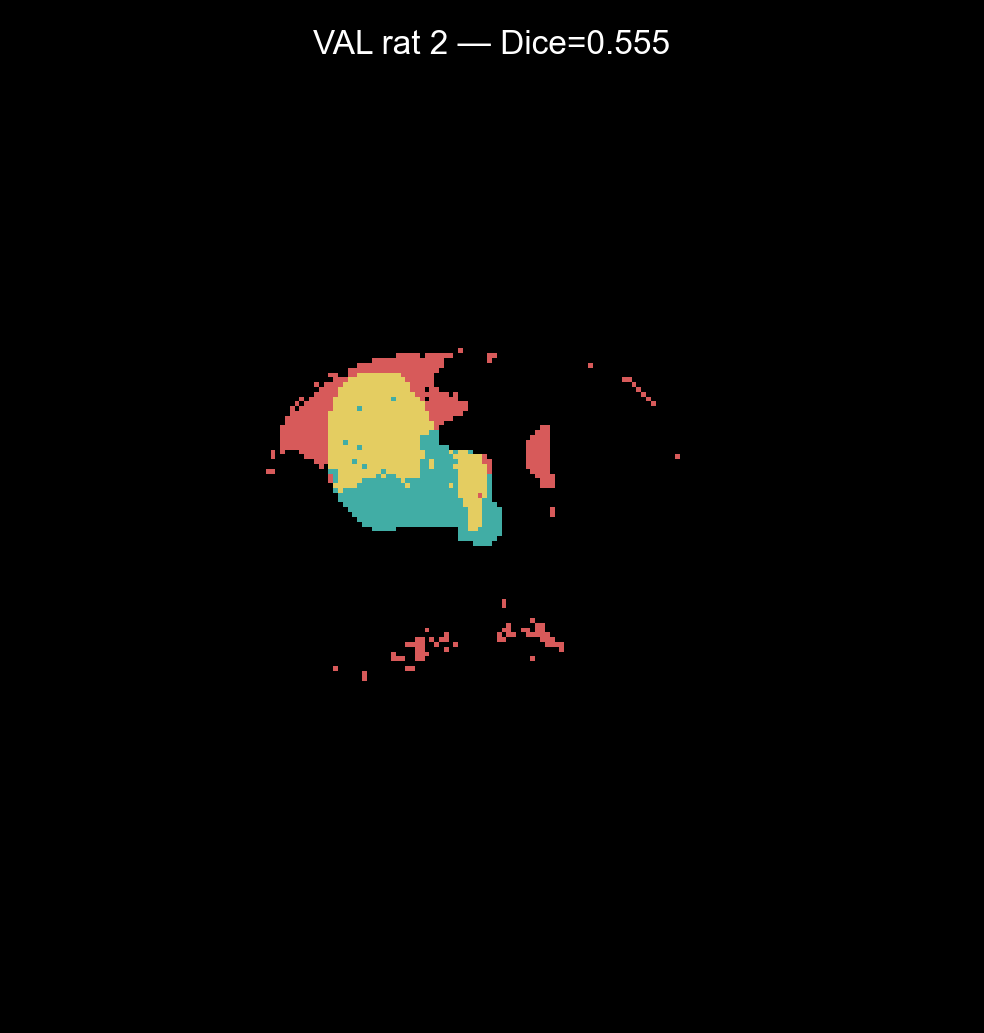

Dice (rat 2, offset 0): 0.5550 | TP=482, P=891, T=846


In [35]:
# Quick overlay vs GT for the validation rat + Dice score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

ri, oi = 2, 0  # rat index, offset index

# Masks
pred = bin_img_val[ri, :, :, oi].astype(bool)
gt   = (Tumor_Voxel_img[ri, :, :, oi] > 0)  # GT: nonzero → True

# Dice
inter = np.logical_and(pred, gt).sum()
p_sum = pred.sum()
g_sum = gt.sum()
dice = (2 * inter) / (p_sum + g_sum) if (p_sum + g_sum) else 0.0

# Overlay (auto=red, GT=teal, overlap=yellow)
H, W = pred.shape
canvas = np.zeros((H, W, 4), dtype=float)
rgba_auto    = (*to_rgb("#FF6B6B"), 0.85)
rgba_truth   = (*to_rgb("#4ECDC4"), 0.85)
rgba_overlap = (*to_rgb("#FFE66D"), 0.90)

canvas[pred & ~gt] = rgba_auto
canvas[gt & ~pred] = rgba_truth
canvas[pred & gt]  = rgba_overlap

fig, ax = plt.subplots(figsize=(4, 4), facecolor="black")
ax.set_facecolor("black")
ax.imshow(canvas, interpolation="nearest")
ax.axis("off")
ax.set_title(f"VAL rat {ri} — Dice={dice:.3f}", color="white")
plt.show()

print(f"Dice (rat {ri}, offset {oi}): {dice:.4f} | TP={inter}, P={p_sum}, T={g_sum}")


In [36]:

anomaly_score_cae = recon_errors
norm_anom_score_cae = (anomaly_score_cae - np.min(anomaly_score_cae)) / (np.max(anomaly_score_cae) - np.min(anomaly_score_cae))
binary_score_cae = (anomaly_score_cae >=  threshold_unsupervised).astype(int)


In [37]:
try:
    recon_errors_test = recon_errors  # from your earlier cell
except NameError:
    recon_tst = X_test.squeeze(1).cpu().numpy()
    recon_errors_test = reconstruction_error(recon_tst, cae_test_results)

# Sanity check: order is [tumor rows; healthy rows]
assert recon_errors_test.shape[0] == (len(tumor_idx_test) + len(healthy_idx_test)), \
    f"Mismatch: recon_errors_test({recon_errors_test.shape[0]}) vs idx sum({len(tumor_idx_test)+len(healthy_idx_test)})"

# Flat anomaly vector for the full 3-rat grid; fill only TEST indices
Nvox = R * H * W
anom_flat = np.zeros(Nvox, dtype=float)

split_t = len(tumor_idx_test)
anom_flat[tumor_idx_test]   = recon_errors_test[:split_t]
anom_flat[healthy_idx_test] = recon_errors_test[split_t:]

# 3D map and broadcast to 4D (per-offset)
anom_img_3d  = anom_flat.reshape(R, H, W)
anom_img_cae = np.repeat(anom_img_3d[..., None], O, axis=-1)

print("anom_img_cae:", anom_img_cae.shape, " | nonzero voxels:", np.count_nonzero(anom_img_3d))


anom_img_cae: (4, 192, 192, 26)  | nonzero voxels: 9318


(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

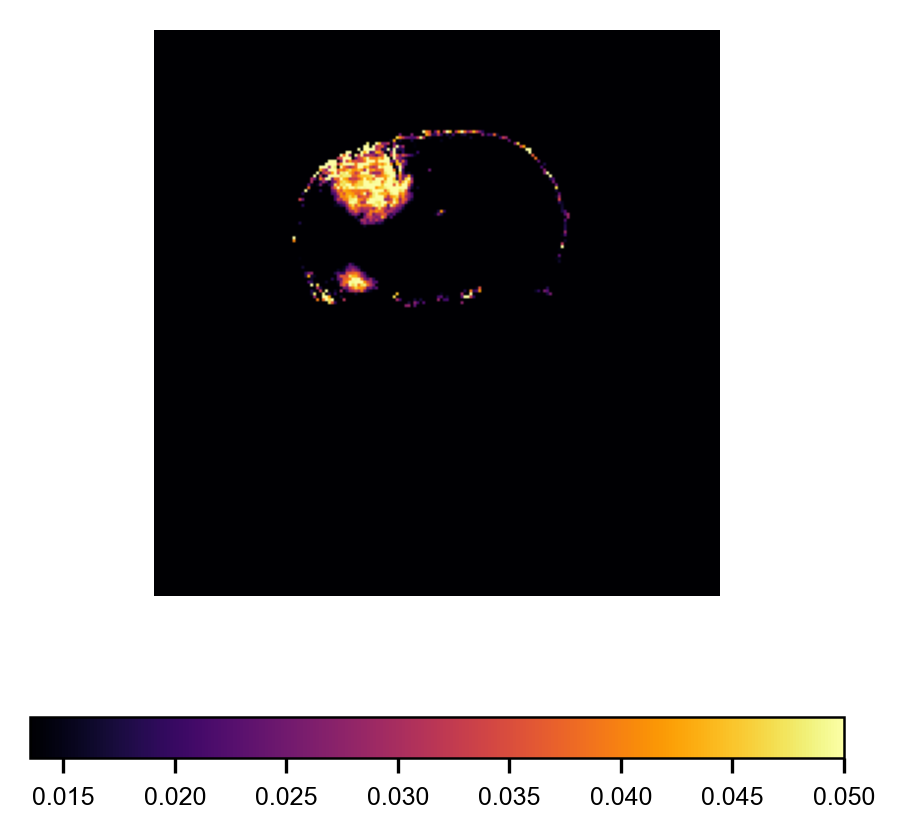

In [38]:
plt.imshow(anom_img_cae[1,:,:,0], cmap = "inferno",vmin= 0.05, vmax = 0.015)
plt.colorbar(orientation= "horizontal")
plt.axis("off")

In [39]:

idx_order = np.concatenate([tumor_idx_test, healthy_idx_test])
assert anomaly_score_cae.shape[0] == idx_order.shape[0], \
    f"Scores length {anomaly_score_cae.shape[0]} != num test voxels {idx_order.shape[0]}"

# 2) Prepare flat canvases (R*H*W, O)
Nvox = R * H * W
flat_norm = np.zeros((Nvox, O), dtype=np.float32)
flat_bin  = np.zeros((Nvox, O), dtype=np.uint8)

# 3) Repeat per-voxel scores across all offsets
norm_2d = np.repeat(norm_anom_score_cae[:, None], O, axis=1).astype(np.float32)  # (N_test, O)
bin_2d  = np.repeat(binary_score_cae[:,  None], O, axis=1).astype(np.uint8)      # (N_test, O)

# 4) Scatter into full grid then reshape
flat_norm[idx_order] = norm_2d
flat_bin[idx_order]  = bin_2d

anom_norm_img_cae = flat_norm.reshape(R, H, W, O)  # continuous (normalized) anomaly map
bin_img_cae       = flat_bin.reshape(R, H, W, O)   # binary mask

# 5) Ensure held-out VAL rat is empty
anom_norm_img_cae[VAL_RAT_ID] = 0.0
bin_img_cae[VAL_RAT_ID]       = 0

print("anom_norm_img_cae:", anom_norm_img_cae.shape,
      "| nonzero @ offset0:", int((anom_norm_img_cae[...,0] > 0).sum()))
print("bin_img_cae:", bin_img_cae.shape,
      "| positives @ offset0:", int(bin_img_cae[...,0].sum()))

# --- Example quick plots (optional) ---
# plot_anomaly_maps(anom_norm_img_cae, offset_idx=0,
#                   rat_indices=tuple(i for i in range(R) if i != VAL_RAT_ID),
#                   vmin=0.0, vmax=0.07, pad_crop=5, cmap="inferno")
# fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")


anom_norm_img_cae: (4, 192, 192, 26) | nonzero @ offset0: 9317
bin_img_cae: (4, 192, 192, 26) | positives @ offset0: 1205


In [40]:

idx_order = np.concatenate([tumor_idx_test, healthy_idx_test])
assert anomaly_score_cae.shape[0] == idx_order.shape[0], \
    f"Scores length {anomaly_score_cae.shape[0]} != num test voxels {idx_order.shape[0]}"

# 2) Prepare flat canvases (R*H*W, O)
Nvox = R * H * W
flat_norm = np.zeros((Nvox, O), dtype=np.float32)
flat_bin  = np.zeros((Nvox, O), dtype=np.uint8)

# 3) Repeat per-voxel scores across all offsets
norm_2d = np.repeat(norm_anom_score_cae[:, None], O, axis=1).astype(np.float32)  # (N_test, O)
bin_2d  = np.repeat(binary_score_cae[:,  None], O, axis=1).astype(np.uint8)      # (N_test, O)

# 4) Scatter into full grid then reshape
flat_norm[idx_order] = norm_2d
flat_bin[idx_order]  = bin_2d

anom_norm_img_cae = flat_norm.reshape(R, H, W, O)  # continuous (normalized) anomaly map
bin_img_cae       = flat_bin.reshape(R, H, W, O)   # binary mask

# 5) Ensure held-out VAL rat is empty
anom_norm_img_cae[VAL_RAT_ID] = 0.0
bin_img_cae[VAL_RAT_ID]       = 0

print("anom_norm_img_cae:", anom_norm_img_cae.shape,
      "| nonzero @ offset0:", int((anom_norm_img_cae[...,0] > 0).sum()))
print("bin_img_cae:", bin_img_cae.shape,
      "| positives @ offset0:", int(bin_img_cae[...,0].sum()))

# --- Example quick plots (optional) ---
# plot_anomaly_maps(anom_norm_img_cae, offset_idx=0,
#                   rat_indices=tuple(i for i in range(R) if i != VAL_RAT_ID),
#                   vmin=0.0, vmax=0.07, pad_crop=5, cmap="inferno")
# fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")


anom_norm_img_cae: (4, 192, 192, 26) | nonzero @ offset0: 9317
bin_img_cae: (4, 192, 192, 26) | positives @ offset0: 1205


In [41]:
# fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")

In [42]:
# # assuming you’ve imported from utils:
# # from utils import plot_zspec_recon_and_residuals

# offset_axis = np.linspace(-4, 4, 26)
# fig, axes = plot_zspec_recon_and_residuals(
#     orig=X_test,                # (N,1,52) or (N,52) or torch.Tensor
#     rec=cae_test_results,       # (N,52)
#     y_true=rat_test_labels,     # (N,)
#     offset_axis=offset_axis,
#     save_path=None,             # e.g., "zspec_summary.pdf"
#     show=True
# )



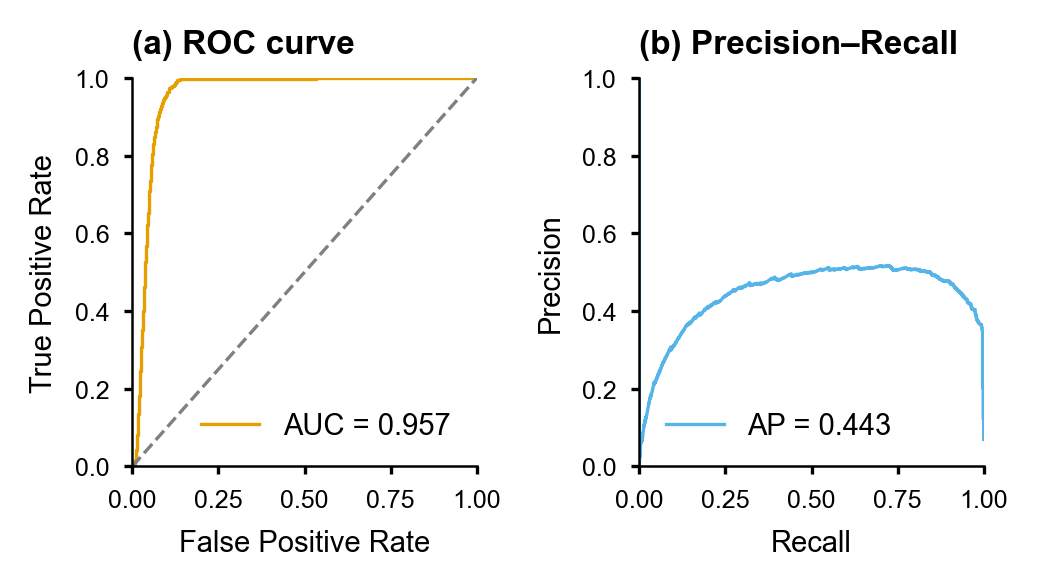

In [43]:
fig, axes = plot_roc_pr(y_true=rat_test_labels, scores=recon_errors,
                        pos_label=1, save_path=None, show=True)


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Compute ROC
fpr1, tpr1, _ = roc_curve(rat_test_labels, recon_errors)
auc1 = roc_auc_score(rat_test_labels, recon_errors)

# Save ROC data
np.savez("roc26Offset_Optimal.npz", fpr=fpr1, tpr=tpr1, auc=auc1)

print("Saved ROC data to roc26Offset_Optimal.npz")


Saved ROC data to roc26Offset_Optimal.npz


In [45]:
nifti_image = nib.load('./data/CDF1T1.nii')
cdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('./data/SDF1T1.nii')
sdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('./data/SDF4T1.nii')
sdf4_T1 = nifti_image.get_fdata()
#
cdf1_T1 = np.rot90(cdf1_T1[:, :, 5],k = 3)

sdf4_T1 = np.rot90(sdf4_T1[:, :, 4],k = 3)

sdf1_T1 = np.rot90(sdf1_T1[:, :, 6],k = 3)

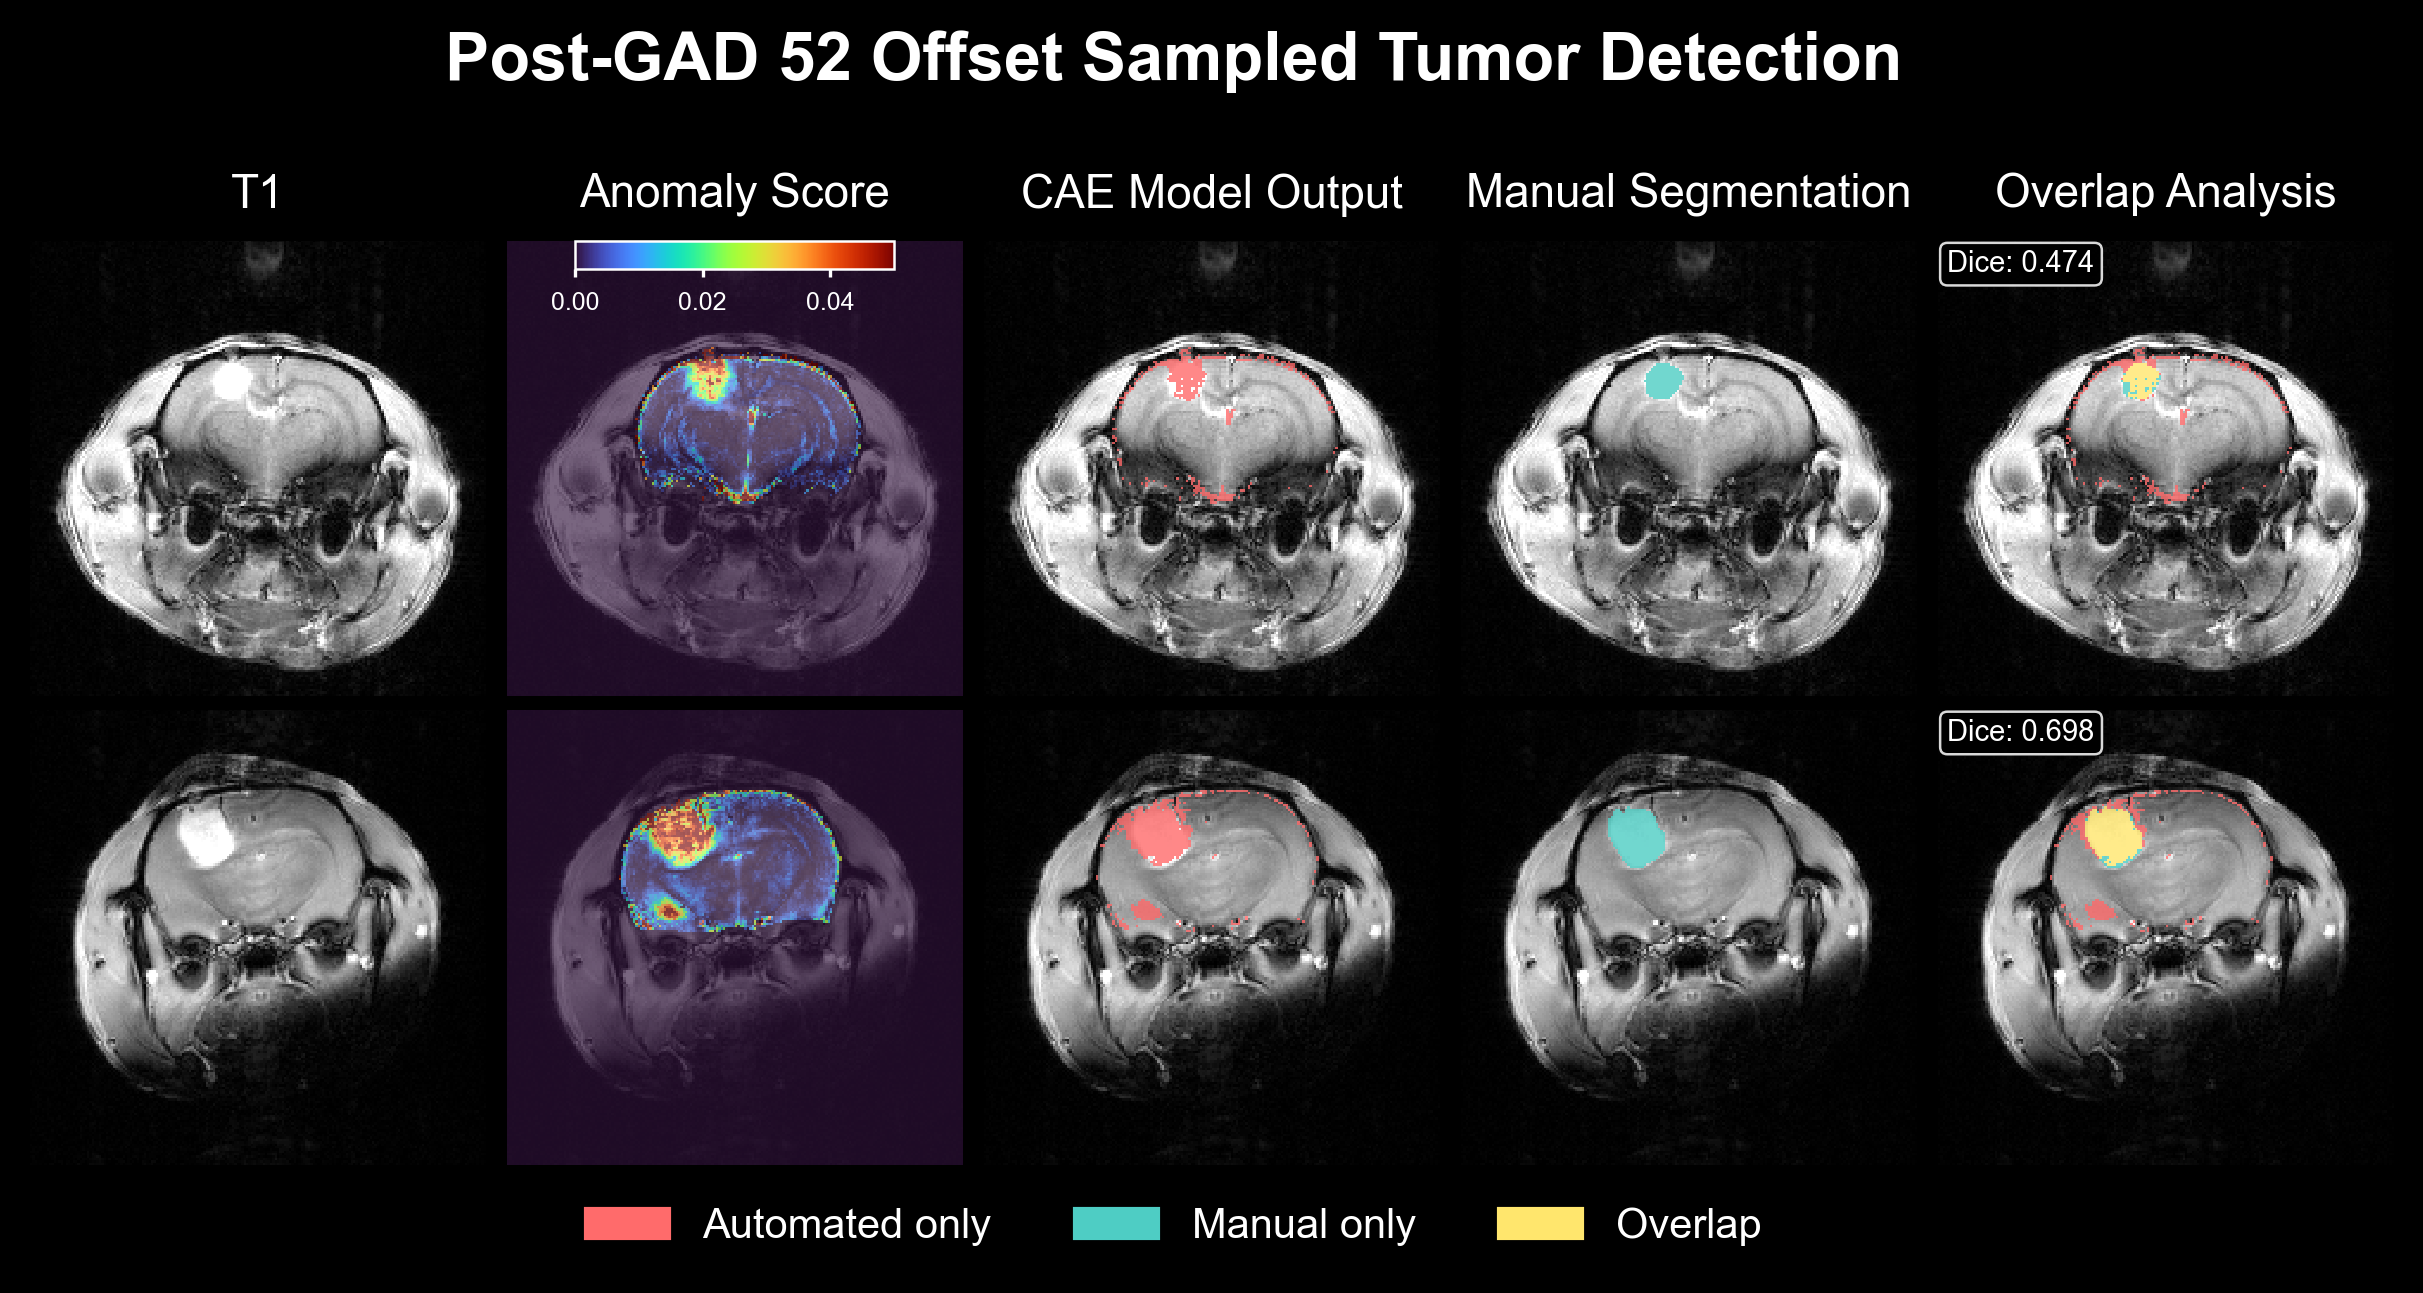

(<Figure size 3060x1320 with 11 Axes>,
 array([[<Axes: title={'center': 'T1'}>,
         <Axes: title={'center': 'Anomaly Score'}>,
         <Axes: title={'center': 'CAE Model Output'}>,
         <Axes: title={'center': 'Manual Segmentation'}>,
         <Axes: title={'center': 'Overlap Analysis'}>],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [46]:
plt.style.use('dark_background')  
t1_slices = (sdf4_T1, cdf1_T1, sdf1_T1)
auto2d  = bin_img_cae[..., 0].astype(bool)      # (3,H,W)
truth2d = Tumor_Voxel_img[..., 0].astype(bool)  # (3,H,W)

anom_3xHW = np.stack([
    anom_img_cae[0, ..., 0],
    anom_img_cae[1, ..., 0],
    anom_img_cae[2, ..., 0],
], axis=0)

plot_masks_over_t1_slices(
    t1_slices,
    auto2d,
    truth2d,
    anom_maps=anom_3xHW,
    anom_cmap='turbo',
    anom_vmin = 0,
    anom_vmax = 0.05,
    anom_alpha=0.65,
    save_path="tumor_detection_with_blankT1.png"
)


In [47]:

def load_rotate_transpose(path):
    vols     = np.load(path)["data"]          # (5, 192, 192)
    vols_rot = np.rot90(vols, k=-1, axes=(1,2))
    arr      = np.transpose(vols_rot, (1,2,0))  # (192, 192, 5)
    return arr
SDF1 = load_rotate_transpose('./data/sdf1.npz')
print("SDF1 shape:", SDF1.shape)
SDF4 = load_rotate_transpose('./data/sdf4.npz')
print("SDF4 shape:", SDF4.shape)
CDF1 = load_rotate_transpose('./data/cdf1.npz')
print("CDF1 shape:", CDF1.shape)
CDF3 = load_rotate_transpose('./data/cdf3.npz')
CDF3 = CDF3.transpose(1,2,0)
print("CDF3 shape:", CDF3.shape)

SDF1 shape: (192, 192, 5)
SDF4 shape: (192, 192, 5)
CDF1 shape: (192, 192, 5)
CDF3 shape: (192, 192, 5)


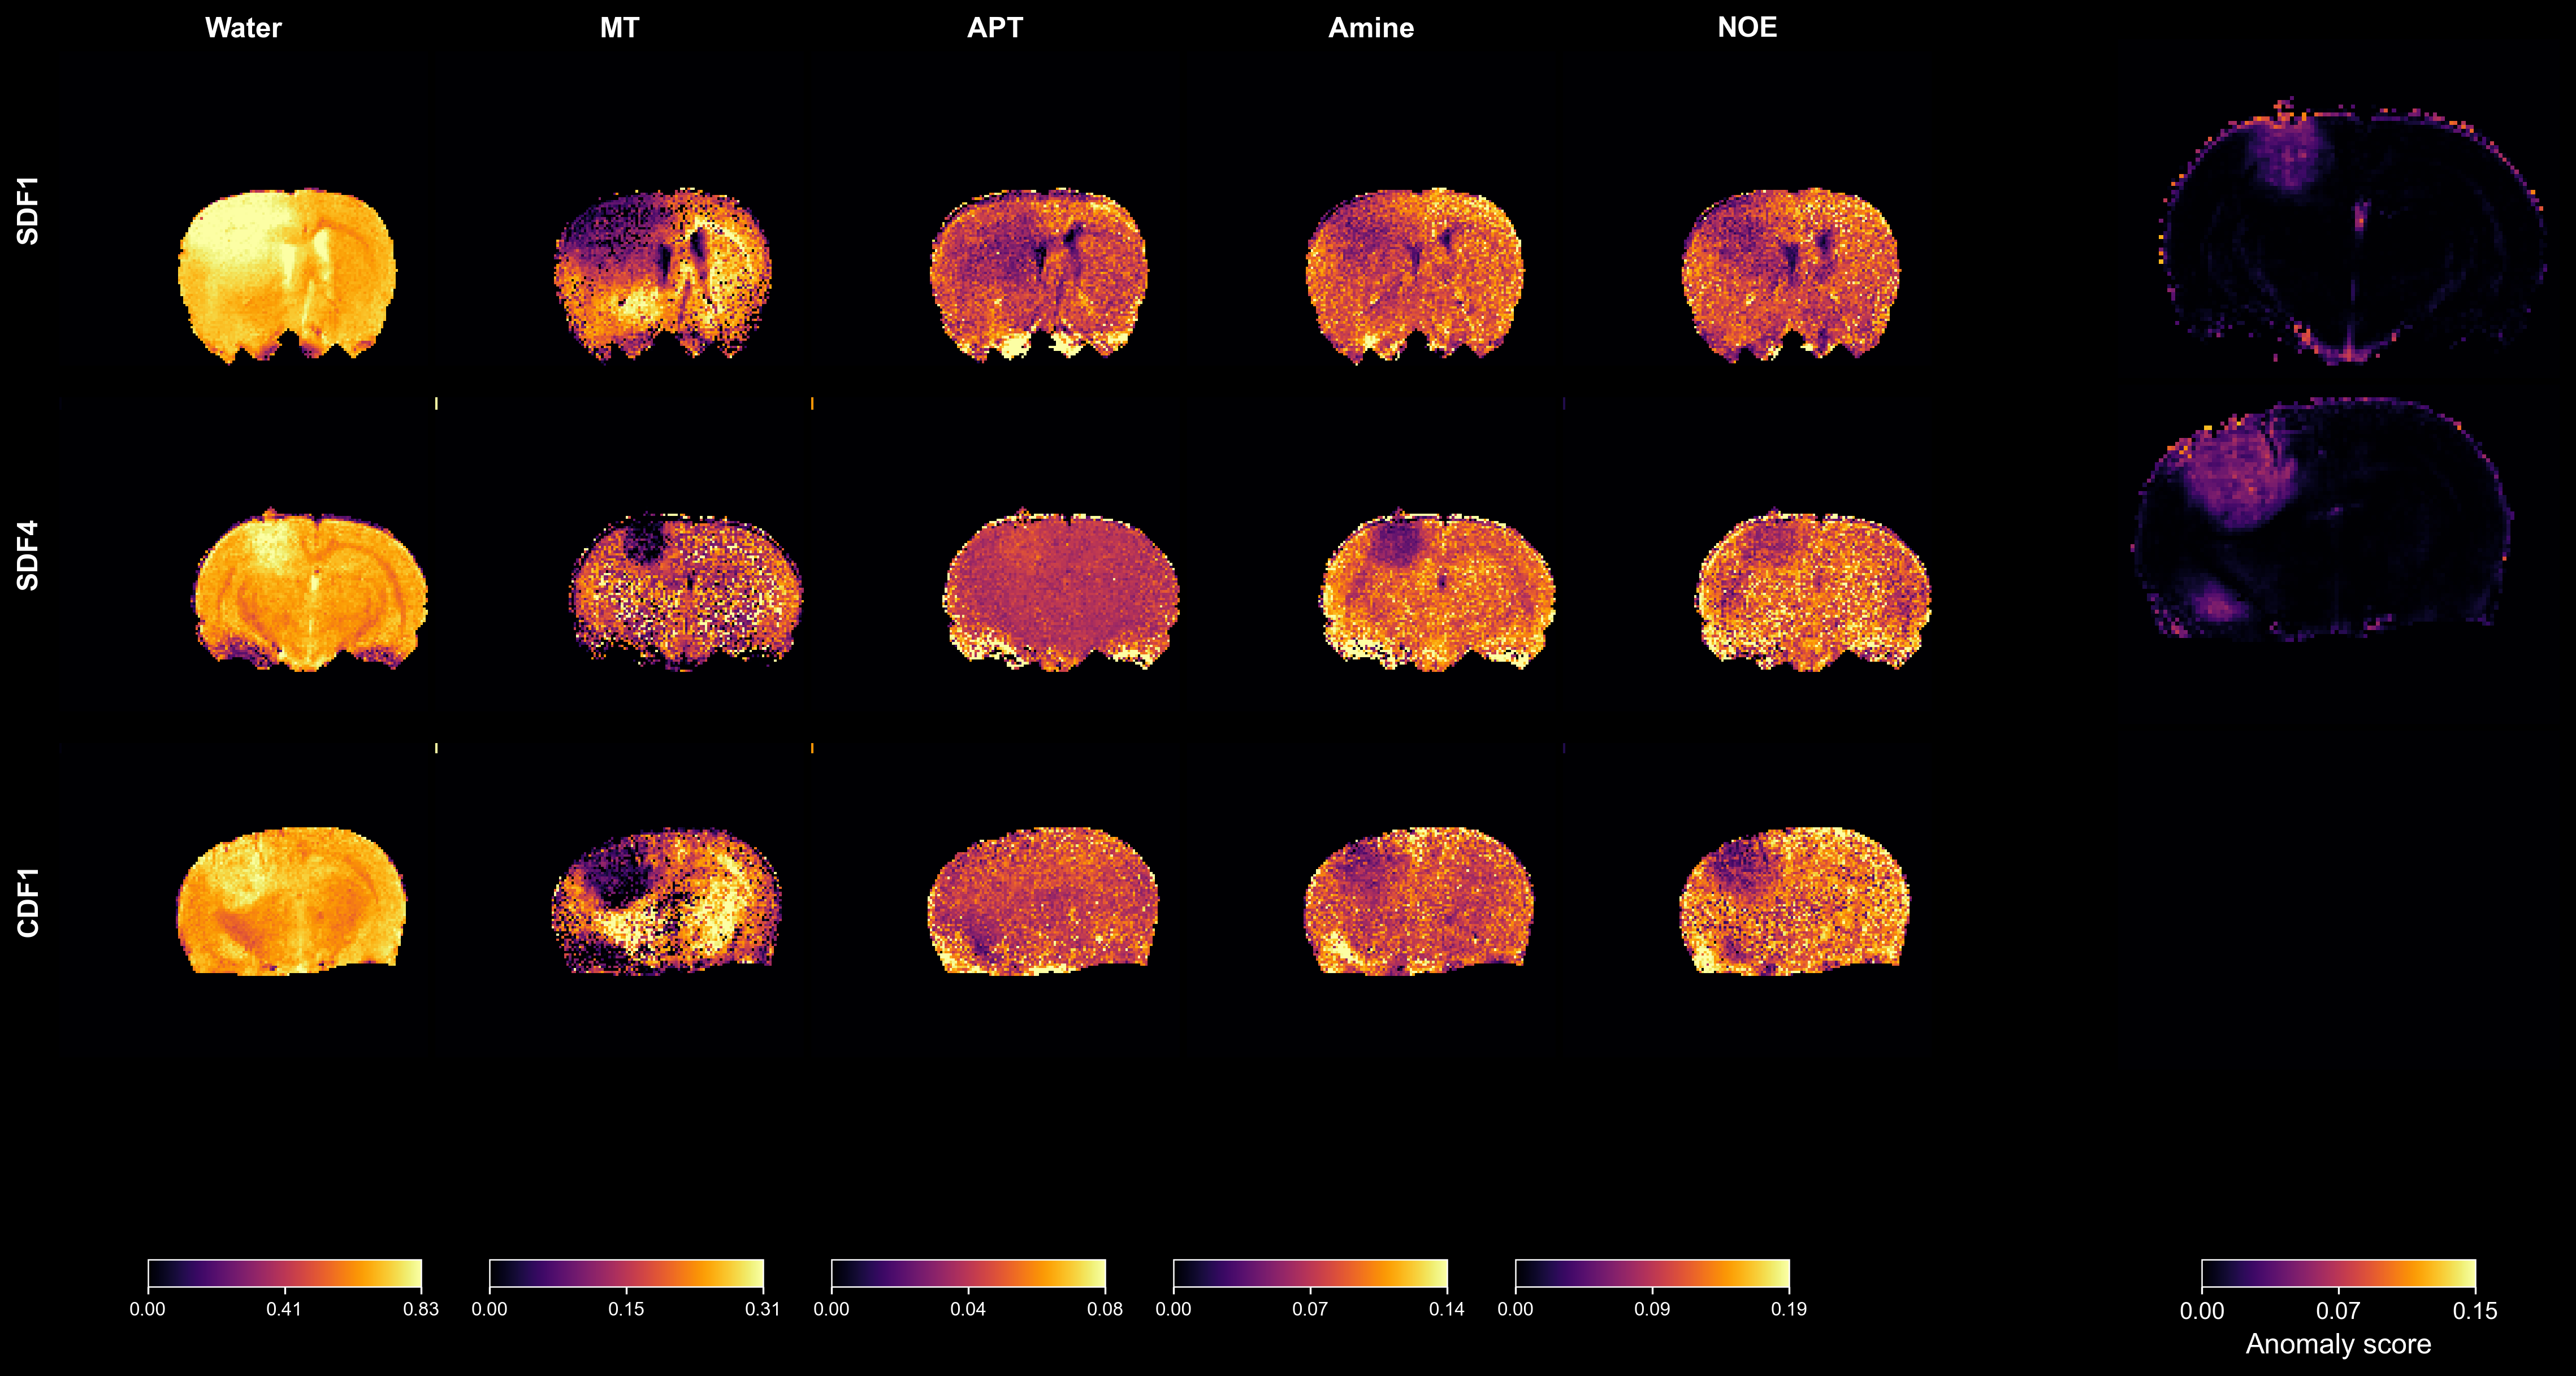

In [48]:
fig = plot_combined_grid_and_anomaly(SDF1, SDF4, CDF1, anom_img_cae)
plt.show()


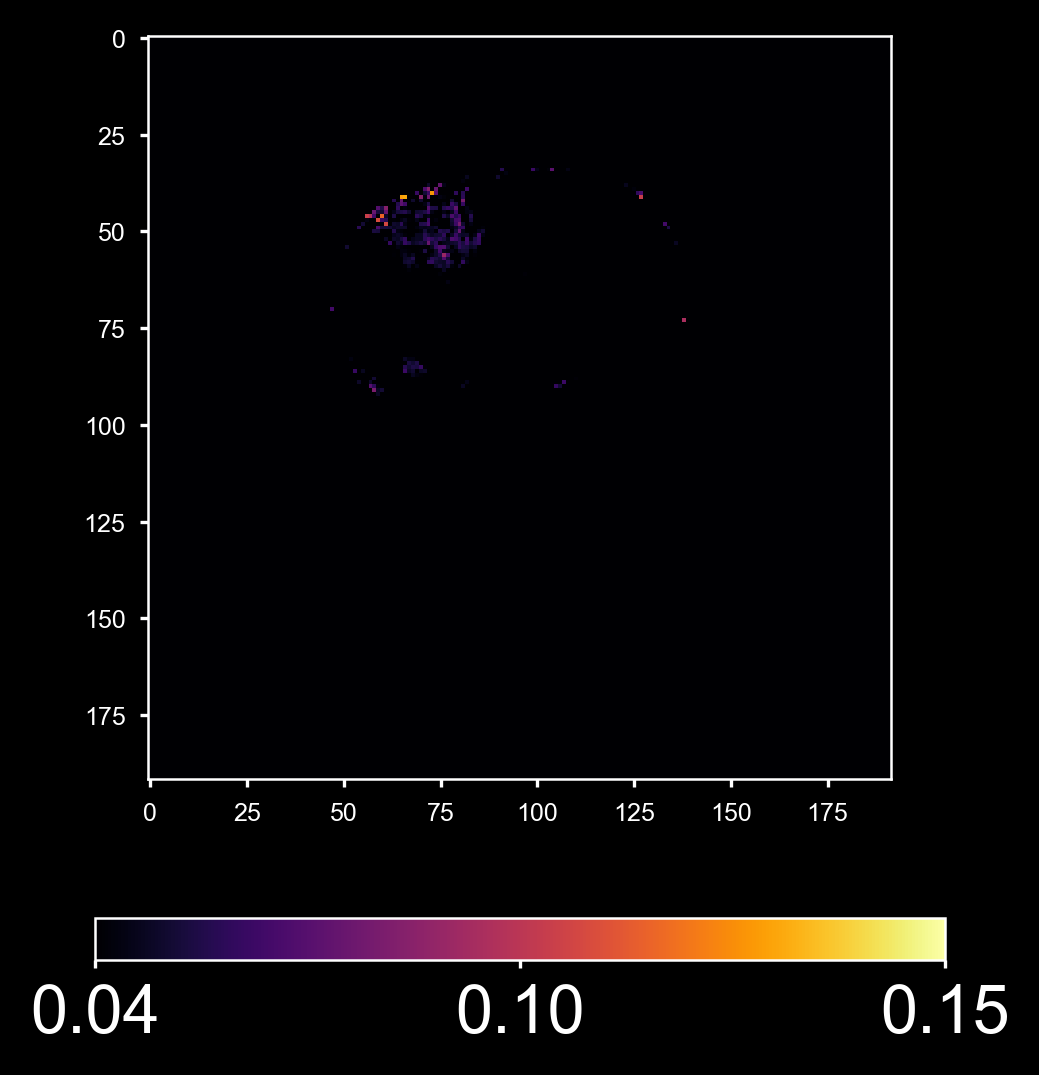

In [49]:
import numpy as np
import matplotlib.pyplot as plt

img = anom_img_cae[1, :, :, 0]
vmin, vmax = 0.04, 0.15
vmid = (vmin + vmax) / 2

plt.figure(figsize=(4,4))
im = plt.imshow(img, vmin=vmin, vmax=vmax, cmap="inferno")

# horizontal colorbar with extra spacing (pad)
cbar = plt.colorbar(im, orientation="horizontal", fraction=0.046, pad=0.15)

# ticks at min / middle / max
cbar.set_ticks([vmin, vmid, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", f"{vmid:.2f}", f"{vmax:.2f}"])

# fontsize = 16
cbar.ax.tick_params(labelsize=16)

plt.show()


In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score, recall_score
)

# --- 1) Prep data ---
orig = np.asarray(X_test).squeeze()        # (N, 52) from torch.Tensor or np
rec  = np.asarray(cae_test_results)       # (N, 52)
y    = np.asarray(rat_test_labels)        # (N,)

# CAE anomaly score = MAE per voxel
scores = np.mean((orig - rec)**2, axis=1)

# --- 2) Metrics ---
# ROC / AUC
fpr, tpr, thr = roc_curve(y, scores)
roc_auc = roc_auc_score(y, scores)

# PR / AUC
prec_arr, rec_arr, _ = precision_recall_curve(y, scores)
pr_auc = average_precision_score(y, scores)

# best threshold via Youden's J
j = tpr - fpr
best_thr = threshold_unsupervised

y_pred = (scores >= best_thr).astype(int)

acc  = accuracy_score(y, y_pred)
f1   = f1_score(y, y_pred)
prec = precision_score(y, y_pred)
rec_ = recall_score(y, y_pred)

# --- 3) One-row DataFrame for CAE ---
df_cae = pd.DataFrame([{
    "Model": "CAE",
    "Accuracy": acc,
    "F1": f1,
    "ROC AUC": roc_auc,
    "PR AUC": pr_auc,
    "Precision": prec,
    "Recall": rec_,
    "Dice 1": None,   # fill in if you have it
    "Dice 2": None,   # fill in if you have it
}]).round(3)

df_cae



,Model,Accuracy,F1,ROC AUC,PR AUC,Precision,Recall,Dice 1,Dice 2
0,CAE,0.925,0.621,0.957,0.443,0.477,0.887,None,None


In [51]:
# Ensure folder exists
os.makedirs("./metrics", exist_ok=True)

y_true = np.asarray(rat_test_labels)
scores = np.asarray(recon_errors)

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)

# ------------------
# PR + AP
# ------------------
prec_curve, rec_curve, _ = precision_recall_curve(y_true, scores)
pr_auc = average_precision_score(y_true, scores)


threshold = threshold_unsupervised
y_pred = (scores >= threshold).astype(int)


acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)

np.savez(
    "./metrics/metrics_26Offset_Optimal.npz",
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc,
    pr_auc=pr_auc,
    accuracy=acc,
    f1=f1,
    precision=prec,
    recall=rec,
    threshold=threshold
)

print("Saved to ./metrics/metrics_26Offset_Optimal.npz")
print("Threshold used:", threshold)


Saved to ./metrics/metrics_26Offset_Optimal.npz
Threshold used: 0.022857662
